In [1]:
import numpy as np
import matplotlib.pylab as pl
import matplotlib.animation as animation
import torch
import torch.nn.functional as F
import ot

In [2]:
# Data generation

N = 500
x0 = torch.rand(N, 3)
x0 = F.normalize(x0, dim=-1)

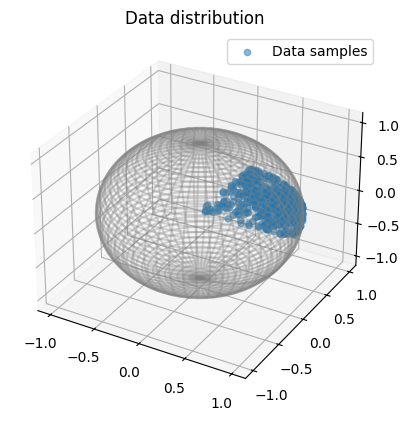

In [3]:
# Plot data
def plot_sphere(ax):
    # Create a sphere using spherical coordinates
    phi = np.linspace(0, 2 * np.pi, 100)
    theta = np.linspace(0, np.pi, 100)
    phi, theta = np.meshgrid(phi, theta)

    # Compute the spherical coordinates
    X = np.sin(theta) * np.cos(phi)
    Y = np.sin(theta) * np.sin(phi)
    Z = np.cos(theta)

    # plor the wireframe
    ax.plot_wireframe(X, Y, Z, color="gray", alpha=0.3)

# plot the distributions
pl.figure(1)
ax = pl.axes(projection="3d")
plot_sphere(ax)
ax.scatter(x0[:, 0], x0[:, 1], label="Data samples", alpha=0.5)
ax.set_title("Data distribution")
pl.legend()

## Gradient descent

Iter:   0, loss=0.21003155410289764


Text(0.5, 0, 'Iterations')

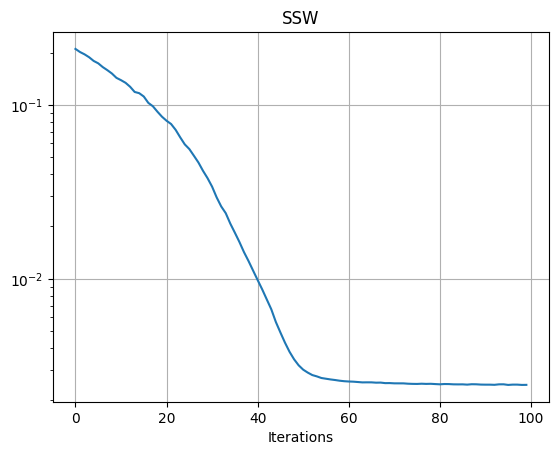

In [4]:
x = x0.clone()
x.requires_grad_(True)

n_iter = 100
lr = 150

losses = []
xvisu = torch.zeros(n_iter, N, 3)

for i in range(n_iter):
    sw = ot.sliced_wasserstein_sphere_unif(x, n_projections=500)
    grad_x = torch.autograd.grad(sw, x)[0]

    x = x - lr * grad_x / np.sqrt(i / 10 + 1)
    x = F.normalize(x, p=2, dim=1)

    losses.append(sw.item())
    xvisu[i, :, :] = x.detach().clone()

    if i % 100 == 0:
        print("Iter: {:3d}, loss={}".format(i, losses[-1]))

pl.figure(1)
pl.semilogy(losses)
pl.grid()
pl.title("SSW")
pl.xlabel("Iterations")